In [3]:
import sqlite3
from pathlib import Path

# Use the correct path to your DB file in Drive
# PROJECT_ROOT = Path(__file__).resolve().parent.parent
# db_path = PROJECT_ROOT / "Underwriter_Data.db"
db_path = r"C:\Users\jaisw\OneDrive\Desktop\Astra Github\Insurance-Project\Underwriter_Data.db"

import vanna as vn
from vanna.remote import VannaDefault
import os
from dotenv import load_dotenv

load_dotenv()
vanna_api_key = os.getenv("vanna_api_key")
vanna_model_name = os.getenv("vanna_model_name")

In [4]:
vn = VannaDefault(model=vanna_model_name, api_key=vanna_api_key)
vn.connect_to_sqlite(str(db_path))
vn.allow_llm_to_see_data = True

SQL Prompt: [{'role': 'system', 'content': "You are a SQLite expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \n\nCREATE TABLE underwriting_dataset (\n\tinsured_name TEXT,\n\tinsured_address TEXT,\n    country_of_incorporation TEXT,\n    business_description TEXT,\n    risk_type TEXT,\n\tbroker_contact TEXT,\n\tclass_of_business TEXT,\n\tsubmission_date DATE,\n    claims_frequency INT,\n    largest_single_loss FLOAT,\n    incurred_loss FLOAT,\n    ultimate_premium FLOAT,\n    loss_ratio FLOAT,\n    tiv FLOAT \n);\n\n\n\n===Additional Context \n\n\n\nUnderwriting_Dataset Table Documentation\n=========================================\n\nThis table contains structured underwriting portfolio data used for AI-driven risk benchmarking,\nloss performance analysis, broker evaluation, and underwriting decision support.\n\n----------------------------

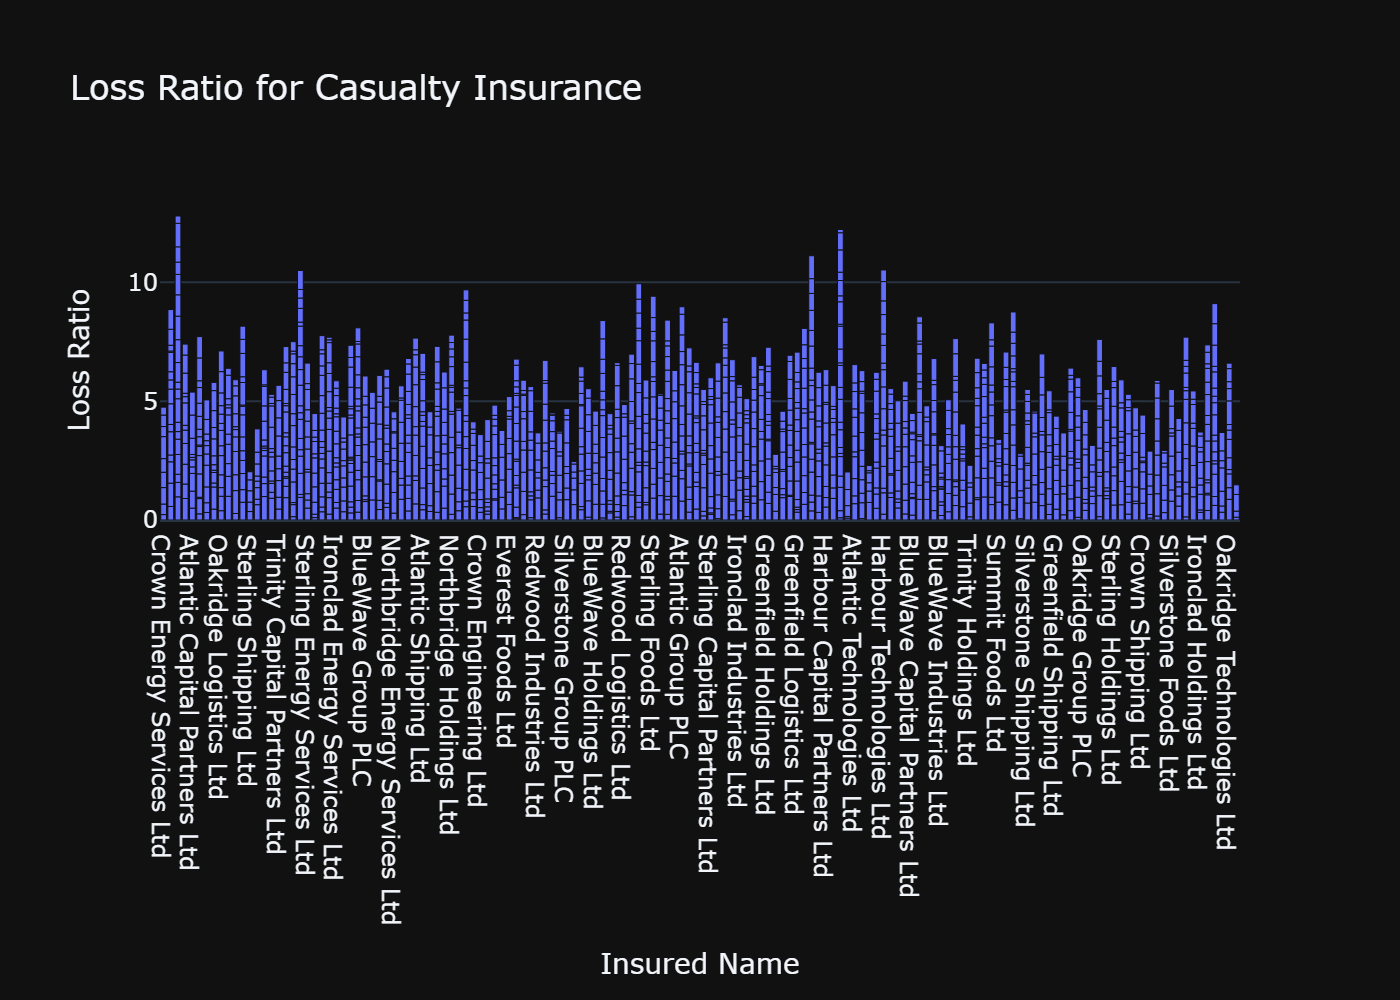

("SELECT insured_name, loss_ratio\n    FROM underwriting_dataset\n    WHERE class_of_business = 'Casualty';",
                        insured_name  loss_ratio
 0         Crown Energy Services Ltd      0.2277
 1           Oakridge Industries Ltd      0.5706
 2         Silverstone Logistics Ltd      0.9741
 3              Crown Industries Ltd      0.9048
 4     Atlantic Capital Partners Ltd      0.4990
 ...                             ...         ...
 1713       Harbour Technologies Ltd      0.4871
 1714             Sterling Foods Ltd      0.8969
 1715              Harbour Foods Ltd      0.8442
 1716          Northbridge Group PLC      0.8734
 1717     Summit Energy Services Ltd      0.6881
 
 [1718 rows x 2 columns],
 Figure({
     'data': [{'type': 'bar',
               'x': array(['Crown Energy Services Ltd', 'Oakridge Industries Ltd',
                           'Silverstone Logistics Ltd', ..., 'Harbour Foods Ltd',
                           'Northbridge Group PLC', 'Summit Energy Se

In [5]:
vn.ask("Show me loss ratio for casualty insuarnce")